In [46]:
# installs
!pip -q install gdown

# core
import re
import gdown
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# statsmodels
import patsy
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV


# Initial inspection and loads

In [47]:
# Read Parquet
gdown.download(
    "https://drive.google.com/uc?id=1v59vFPEgfXPvCbp7wTnBiqtfq5X5BYBi",
    "data.parquet",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1v59vFPEgfXPvCbp7wTnBiqtfq5X5BYBi
To: /content/data.parquet
100%|██████████| 43.4M/43.4M [00:00<00:00, 132MB/s]


'data.parquet'

In [48]:
# filter for multiple years since 2021
df = pd.read_parquet("data.parquet")
df = df[df["ROLL_YEAR"].isin([2022, 2023, 2024, 2025])].copy()

In [49]:
# Initial inspect
pd.set_option("display.max_columns", None)
display(df.head(5))

,ROLL_YEAR,ROLL_NUMBER,ADDRESS,ASSESSED_VALUE,ASSESSMENT_CLASS,ASSESSMENT_CLASS_DESCRIPTION,RE_ASSESSED_VALUE,NR_ASSESSED_VALUE,FL_ASSESSED_VALUE,COMM_CODE,COMM_NAME,YEAR_OF_CONSTRUCTION,LAND_USE_DESIGNATION,PROPERTY_TYPE,LAND_SIZE_SM,LAND_SIZE_SF,LAND_SIZE_AC,SUB_PROPERTY_USE,MULTIPOLYGON,CPID,VALUE_PER_SM
6,2022,3002102,8825 52 ST NE,"710,500",RE,Residential,"710,500",NaN,NaN,SAD,SADDLE RIDGE,"2,003",DC,LI,"17,740","190,962",4,RAWDL,"MULTIPOLYGON (((-113.95985 51.130684, -113.958...",250264641,40
7,2023,3002102,8825 52 ST NE,"792,000",RE,Residential,"792,000",NaN,NaN,SAD,SADDLE RIDGE,"2,003",DC,LI,"17,740","190,962",4,RAWDL,"MULTIPOLYGON (((-113.95985 51.130684, -113.958...",250264641,45
8,2024,3002102,8825 52 ST NE,"863,000",RE,Residential,"863,000",NaN,NaN,SAD,SADDLE RIDGE,"2,003",DC,LI,"17,740","190,962",4,RAWDL,"MULTIPOLYGON (((-113.9598464 51.1306877, -113....",250264641,49
9,2025,3002102,8825 52 ST NE,"876,500",RE,Residential,"876,500",NaN,NaN,SAD,SADDLE RIDGE,"2,003",DC,LI,"17,740","190,962",4,RAWDL,"MULTIPOLYGON (((-113.9598606 51.1306945, -113....",250264641,49
19,2022,3003506,5029 84 AV NE,"587,000",RE,Residential,"587,000",NaN,NaN,SAD,SADDLE RIDGE,"1,968",S-FUD,LI,"19,693","211,980",5,RE0100,"MULTIPOLYGON (((-113.9613021 51.1287672, -113....",310264647,30


# Feature cleaning and engineering

In [50]:
# Remove features which don't seem useful for ML analysis
df = df.drop(columns=["LAND_SIZE_SF", "LAND_SIZE_AC", "ASSESSMENT_CLASS_DESCRIPTION", "RE_ASSESSED_VALUE", "NR_ASSESSED_VALUE", "FL_ASSESSED_VALUE", "LAND_USE_DESIGNATION", "SUB_PROPERTY_USE", "COMM_NAME"])

In [51]:
# Extract all lon/lat pairs from the polygon and take their average
def avg_center_point(wkt):
    if pd.isna(wkt):
        return pd.Series([None, None])

    coords = re.findall(r'(-?\d+\.\d+)\s+(-?\d+\.\d+)', str(wkt))
    if not coords:
        return pd.Series([None, None])

    lons = [float(x[0]) for x in coords]
    lats = [float(x[1]) for x in coords]

    return pd.Series([sum(lons) / len(lons), sum(lats) / len(lats)])

df[["center_longitude", "center_latitude"]] = df["MULTIPOLYGON"].apply(avg_center_point)

# Drop original multipolygon column too
df = df.drop(columns=["MULTIPOLYGON"])

In [52]:
# Fill missing construction years with median based on community and assessment class
# Engineered features used for the Single Year analysis were added to the

df["YEAR_BUILT_MISSING"] = df["YEAR_OF_CONSTRUCTION"].isna().astype(int)

df["YEAR_OF_CONSTRUCTION"] = (
    df.groupby(["COMM_CODE", "ASSESSMENT_CLASS"])["YEAR_OF_CONSTRUCTION"]
      .transform(lambda x: x.fillna(x.median()))
)

df["YEAR_OF_CONSTRUCTION"] = df["YEAR_OF_CONSTRUCTION"].fillna(
    df["YEAR_OF_CONSTRUCTION"].median()
)

# remove indicator
df = df.drop(columns=["YEAR_BUILT_MISSING"])

In [53]:
# AGE OF THE PROPERTY Engineered Feature
df["AGE_OF_PROPERTY"] = df["ROLL_YEAR"] - df["YEAR_OF_CONSTRUCTION"]

In [54]:
# Engineer some more geographical features

# 1) Choose a city-centre point
# Approx downtown Calgary / central core
CALGARY_CENTRE_LAT = 51.0447
CALGARY_CENTRE_LON = -114.0719

# 2) Distance from centre (km)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df["DIST_FROM_CENTRE_KM"] = haversine_km(
    df["center_latitude"],
    df["center_longitude"],
    CALGARY_CENTRE_LAT,
    CALGARY_CENTRE_LON
)

# 3) Quadrant / central feature-
# Central radius in km
CENTRAL_RADIUS_KM = 3.0

def assign_area(lat, lon, dist_km, centre_lat=CALGARY_CENTRE_LAT, centre_lon=CALGARY_CENTRE_LON):
    if pd.isna(lat) or pd.isna(lon):
        return pd.NA

    if dist_km <= CENTRAL_RADIUS_KM:
        return "CENTRAL"

    if lat >= centre_lat and lon >= centre_lon:
        return "NE"
    elif lat >= centre_lat and lon < centre_lon:
        return "NW"
    elif lat < centre_lat and lon >= centre_lon:
        return "SE"
    else:
        return "SW"

df["CITY_AREA"] = df.apply(
    lambda row: assign_area(
        row["center_latitude"],
        row["center_longitude"],
        row["DIST_FROM_CENTRE_KM"]
    ),
    axis=1
)

# Make categorical
df["CITY_AREA"] = pd.Categorical(
    df["CITY_AREA"],
    categories=["CENTRAL", "NW", "NE", "SW", "SE"]
)

# Quick check
print(df[["center_latitude", "center_longitude", "DIST_FROM_CENTRE_KM", "CITY_AREA"]].head())
print(df["CITY_AREA"].value_counts(dropna=False))

    center_latitude  center_longitude  DIST_FROM_CENTRE_KM CITY_AREA
6                51              -114                   12        NE
7                51              -114                   12        NE
8                51              -114                   12        NE
9                51              -114                   12        NE
19               51              -114                   12        NE
CITY_AREA
NW         122126
SE         106232
SW          83507
NE          81827
CENTRAL     61224
Name: count, dtype: int64


In [55]:
# Create an estimate of density
df["COMM_PROPERTY_COUNT"] = df.groupby("COMM_CODE")["ROLL_NUMBER"].transform("count")
df[["COMM_CODE", "COMM_PROPERTY_COUNT"]].drop_duplicates().sample(10)

,COMM_CODE,COMM_PROPERTY_COUNT
458018,SVO,2409
218227,EYA,620
307353,MID,2086
105937,FRA,109
174170,RED,388
313695,MCK,3824
261486,PAL,1084
107948,REN,3185
366833,TUS,5872
697994,ABT,223


# Create train, val, test datasets

In [56]:
# -------------------------
# 1) Multiyear Split considering Validation and Test dataset to be the last two years
# -------------------------
df_train = df[df['ROLL_YEAR'] <= 2023].copy()
df_val   = df[df['ROLL_YEAR'] == 2024].copy()
df_test  = df[df['ROLL_YEAR'] == 2025].copy()

# -------------------------
# 2) Sampling (20%) – A 20% random sample was taken independently from each dataset split (training, validation, and test) to ensure the model could run efficiently on local computational resources.
#The ROLL_NUMBER variable, which uniquely identified properties across years, was removed so that each record was treated as an independent observation,
#even if the same property appeared multiple times over different years. This assumption of independence enabled proper random sampling within each split.
#However, the data was still partitioned by year to preserve its time-series structure and allow the model to capture t --> t+1 relationships.

# -------------------------
df_train = df_train.sample(frac=0.20, random_state=42)
df_val   = df_val.sample(frac=0.20, random_state=42)
df_test  = df_test.sample(frac=0.20, random_state=42)

# -------------------------
# 3) Reset index
# -------------------------
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

# -------------------------
# 4) Verification
# -------------------------
print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))

Train size: 44467
Val size: 22994
Test size: 23522


# Final feature analysis and visuals

In [57]:
# Numerical features
pd.set_option("display.float_format", "{:,.0f}".format)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ROLL_YEAR,"454,916","2,024",1,"2,022","2,023","2,024","2,025","2,025"
ROLL_NUMBER,"454,916","181,138,665","140,256,018","3,002,102","83,193,201","200,385,574","202,095,599","903,001,303"
ASSESSED_VALUE,"454,916","731,732","7,603,527",70,"278,000","476,000","661,000","1,589,540,000"
YEAR_OF_CONSTRUCTION,"454,916","1,993",21,"1,893","1,978","1,999","2,009","2,024"
LAND_SIZE_SM,"454,916","4,473","57,220",0,385,556,"2,330","13,342,400"
VALUE_PER_SM,"454,916","1,089","9,450",0,91,"1,034","1,525","2,266,667"
center_longitude,"454,916",-114,0,-114,-114,-114,-114,-114
center_latitude,"454,916",51,0,51,51,51,51,51
AGE_OF_PROPERTY,"454,916",30,21,-2,14,24,45,132
DIST_FROM_CENTRE_KM,"454,916",10,5,0,6,10,15,24


In [58]:
# Categorical features
df.describe(include=["object", "string", "category"]).T

,count,unique,top,freq
ADDRESS,454916,117619,3025 SPILLER RD SE,552
ASSESSMENT_CLASS,454916,3,RE,433934
COMM_CODE,454916,311,BLN,16636
PROPERTY_TYPE,454916,3,LI,441015
CPID,454916,83875,96142195,924
CITY_AREA,454916,5,NW,122126


/tmp/ipykernel_1094/2797487652.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_avg = df.groupby(['ROLL_YEAR', 'CITY_AREA'])['VALUE_PER_SM'].mean().reset_index()


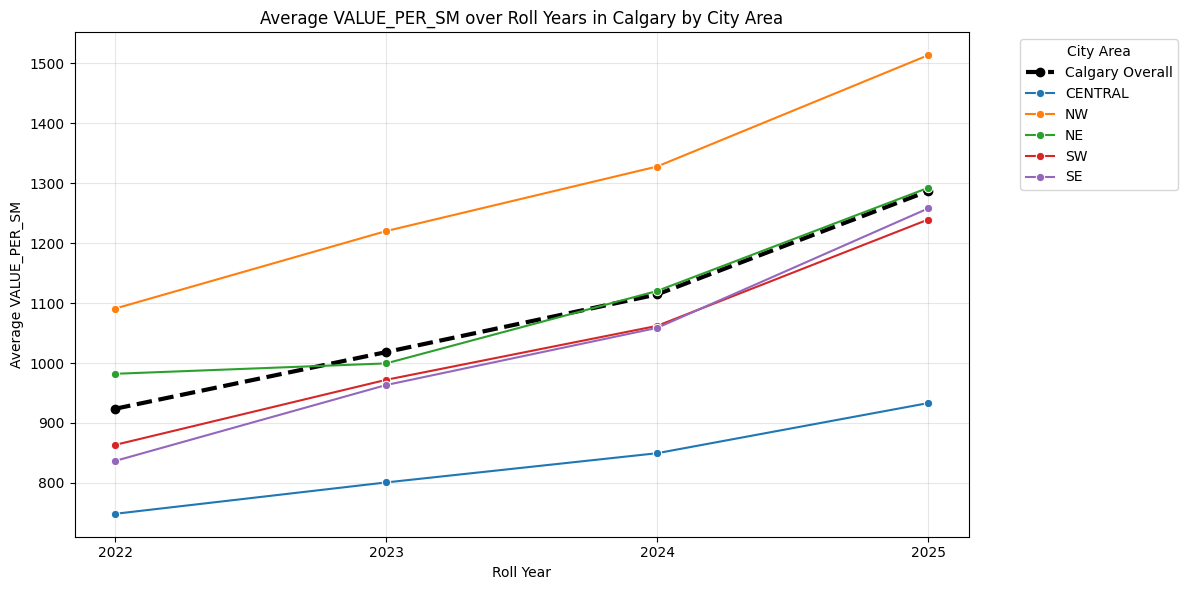

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) Summarize data
# -------------------------
# Average VALUE_PER_SM for all of Calgary
calgary_avg = df.groupby('ROLL_YEAR')['VALUE_PER_SM'].mean().reset_index()
calgary_avg['CITY_AREA'] = 'Calgary Overall'

# Average VALUE_PER_SM by CITY_AREA
area_avg = df.groupby(['ROLL_YEAR', 'CITY_AREA'])['VALUE_PER_SM'].mean().reset_index()

# Combine both for plotting
plot_df = pd.concat([calgary_avg, area_avg], axis=0)

# -------------------------
# 2) Plot
# -------------------------
plt.figure(figsize=(12,6))

# Plot Calgary Overall first with thick dashed line
calgary_data = plot_df[plot_df['CITY_AREA'] == 'Calgary Overall']
plt.plot(calgary_data['ROLL_YEAR'], calgary_data['VALUE_PER_SM'],
         label='Calgary Overall', color='black', linewidth=3, linestyle='--', marker='o')

# Plot CITY_AREA averages with automatic colors
city_area_data = plot_df[plot_df['CITY_AREA'] != 'Calgary Overall']
sns.lineplot(data=city_area_data, x='ROLL_YEAR', y='VALUE_PER_SM', hue='CITY_AREA', marker='o')

# -------------------------
# 3) Final adjustments
# -------------------------
plt.title('Average VALUE_PER_SM over Roll Years in Calgary by City Area')
plt.xlabel('Roll Year')
plt.ylabel('Average VALUE_PER_SM')
plt.xticks(sorted(df['ROLL_YEAR'].unique()))
plt.grid(alpha=0.3)
plt.legend(title='City Area', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

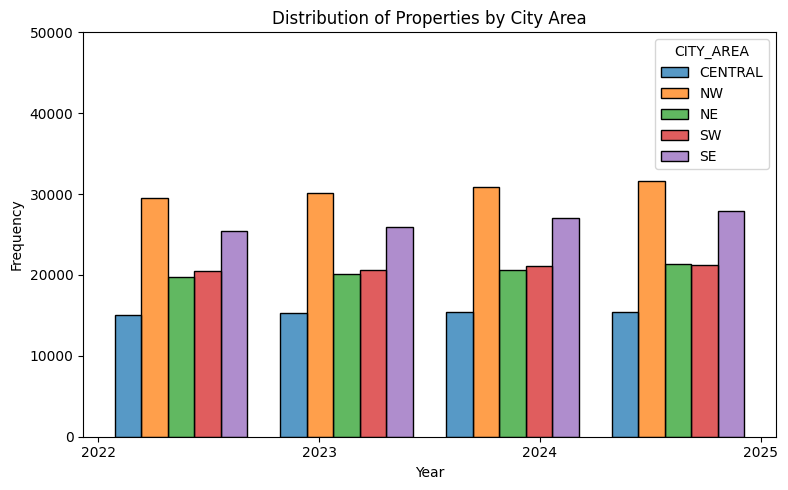

In [60]:
# -------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="ROLL_YEAR",
    hue="CITY_AREA",
    bins=len(df['ROLL_YEAR'].unique()),
    multiple="dodge",
    shrink=0.8   # remove palette to use default colors
)

plt.xlabel("Year")
plt.ylabel("Frequency")
plt.title("Distribution of Properties by City Area")
plt.xticks(sorted(df['ROLL_YEAR'].unique()))
plt.ylim(0, 50000)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1094/2923243833.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bubble_df = df.groupby('CITY_AREA').agg(


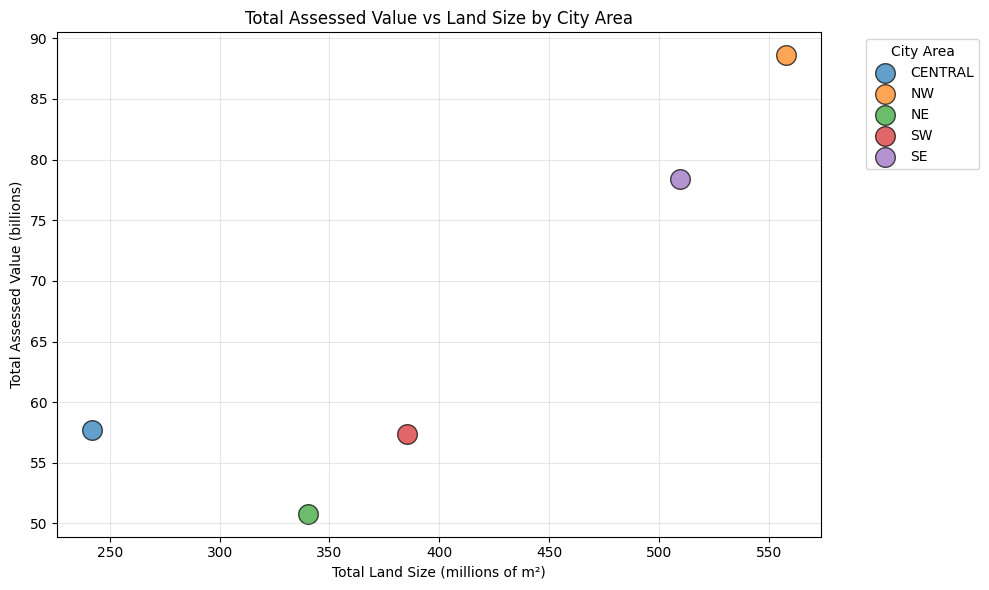

In [61]:


# -------------------------
# 1) Aggregate data per quadrant
# -------------------------
bubble_df = df.groupby('CITY_AREA').agg(
    total_value=('ASSESSED_VALUE', 'sum'),
    total_land=('LAND_SIZE_SM', 'sum')
).reset_index()

# Convert units
bubble_df['total_value_million'] = bubble_df['total_value'] / 1_000_000_000
bubble_df['total_land_thousand'] = bubble_df['total_land'] / 1_000_000

# -------------------------
# 2) Set color palette (default Seaborn)
# -------------------------
city_areas = bubble_df['CITY_AREA'].unique()
palette = sns.color_palette(n_colors=len(city_areas))  # default colors
area_colors = {area: palette[i] for i, area in enumerate(city_areas)}

# -------------------------
# 3) Plot dispersed bubble chart (fixed size)
# -------------------------
plt.figure(figsize=(10,6))

for area in city_areas:
    data = bubble_df[bubble_df['CITY_AREA'] == area]
    plt.scatter(
        x=data['total_land_thousand'],
        y=data['total_value_million'],
        s=200,                           # fixed bubble size
        color=area_colors[area],
        alpha=0.7,
        edgecolor='k',
        label=area
    )

plt.xlabel("Total Land Size (millions of m²)")
plt.ylabel("Total Assessed Value (billions)")
plt.title("Total Assessed Value vs Land Size by City Area")
plt.grid(alpha=0.3)
plt.legend(title='City Area', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

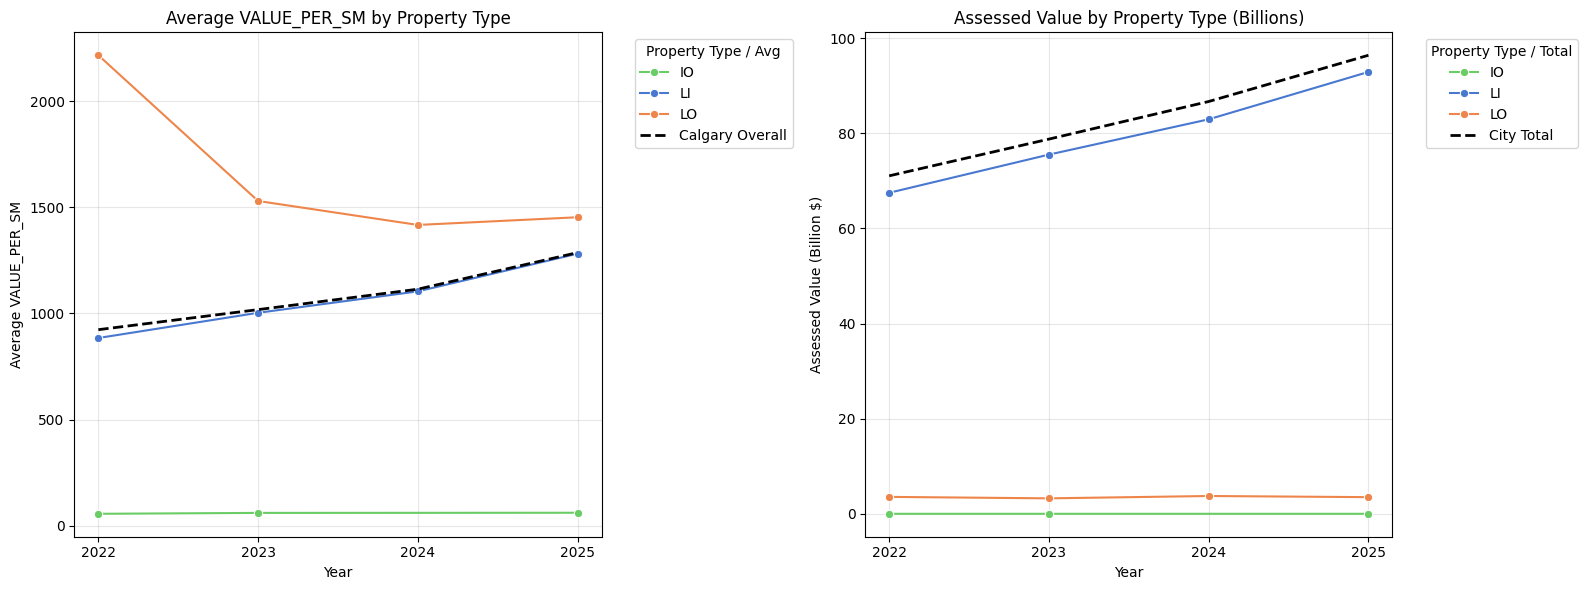

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------
# Optional: filter by property types
# -------------------------
property_filter = ['LO', 'IO', 'LI']  # Land only, Improvements only, Land + Improvements
df_filtered = df[df['PROPERTY_TYPE'].isin(property_filter)].copy()

# -------------------------
# 1) Define property types and consistent color palette
# -------------------------
property_types = df_filtered['PROPERTY_TYPE'].unique()
palette = sns.color_palette("coolwarm", n_colors=len(property_types))  # cooler palette
ptype_colors = {ptype: palette[i] for i, ptype in enumerate(property_types)}

# -------------------------
# 2) Aggregate average VALUE_PER_SM per year and PROPERTY_TYPE
# -------------------------
value_df = df_filtered.groupby(['ROLL_YEAR', 'PROPERTY_TYPE'])['VALUE_PER_SM'].mean().reset_index()

# -------------------------
# 3) Aggregate total ASSESSED_VALUE per year and PROPERTY_TYPE (in billions)
# -------------------------
assessed_df = df_filtered.groupby(['ROLL_YEAR', 'PROPERTY_TYPE'])['ASSESSED_VALUE'].sum().reset_index()
assessed_df['ASSESSED_VALUE'] = assessed_df['ASSESSED_VALUE'] / 1e9  # convert to billions

# -------------------------
# 4) Side-by-side plots
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharex=True)

# --- Plot 1: VALUE_PER_SM by property type ---
# Create palette first
palette = sns.color_palette("muted", n_colors=len(property_types))

# Map each property type to a color
ptype_colors = {ptype: palette[i] for i, ptype in enumerate(property_types)}

# Plot
sns.lineplot(
    data=value_df,
    x='ROLL_YEAR',
    y='VALUE_PER_SM',
    hue='PROPERTY_TYPE',
    marker='o',
    palette=ptype_colors,   # use the dictionary here
    ax=axes[0]
)

# Overlay Calgary overall average (black dashed line)
axes[0].plot(
    calgary_avg['ROLL_YEAR'],
    calgary_avg['VALUE_PER_SM'],
    color='black',
    linestyle='--',
    linewidth=2,
    label='Calgary Overall'
)

axes[0].set_title('Average VALUE_PER_SM by Property Type')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average VALUE_PER_SM')
axes[0].set_xticks(sorted(df['ROLL_YEAR'].unique()))
axes[0].grid(alpha=0.3)
axes[0].legend(title='Property Type / Avg', bbox_to_anchor=(1.05,1), loc='upper left')

# --- Plot 2: ASSESSED_VALUE by property type in billions ---
sns.lineplot(
    data=assessed_df,
    x='ROLL_YEAR',
    y='ASSESSED_VALUE',
    hue='PROPERTY_TYPE',
    marker='o',
    palette=ptype_colors,
    ax=axes[1]
)

# Overlay city-wide total assessed value as dashed black line (in billions)
city_total = df.groupby('ROLL_YEAR')['ASSESSED_VALUE'].sum().reset_index()
city_total['ASSESSED_VALUE'] = city_total['ASSESSED_VALUE'] / 1e9  # convert to billions
axes[1].plot(
    city_total['ROLL_YEAR'],
    city_total['ASSESSED_VALUE'],
    color='black',
    linestyle='--',
    linewidth=2,
    label='City Total'
)

axes[1].set_title('Assessed Value by Property Type (Billions)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Assessed Value (Billion $)')
axes[1].set_xticks(sorted(df['ROLL_YEAR'].unique()))
axes[1].grid(alpha=0.3)
axes[1].legend(title='Property Type / Total', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()

#LO Land ONLY
#IO Inprovement ONLY
#LI Land + improvements

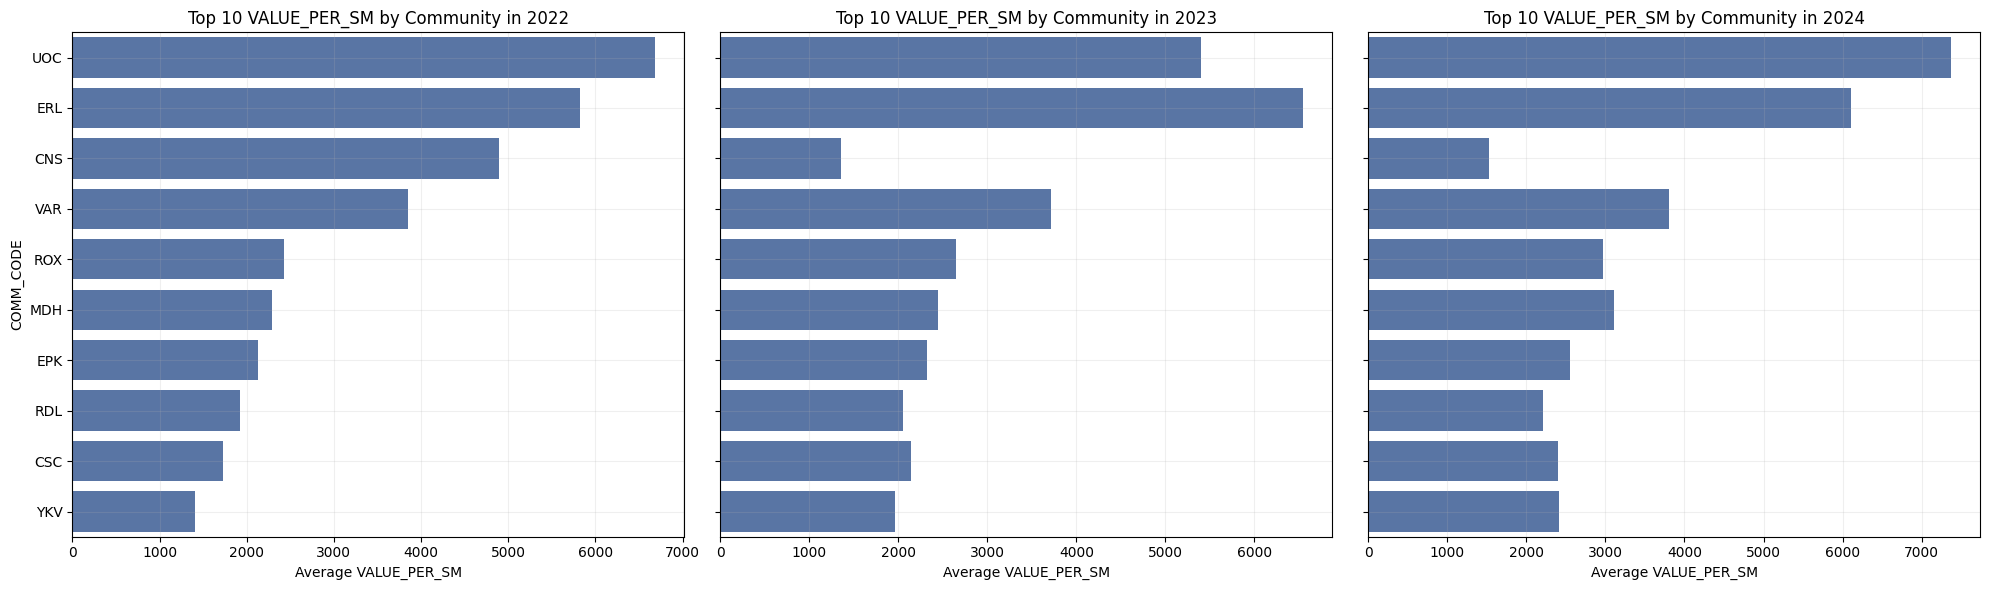

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) Filter years of interest
# -------------------------
years = [2022, 2023, 2024]
plot_df = df[df['ROLL_YEAR'].isin(years)]

# -------------------------
# 2) Aggregate average VALUE_PER_SM per COMM_CODE per year
# -------------------------
comm_avg = plot_df.groupby(['ROLL_YEAR', 'COMM_CODE'])['VALUE_PER_SM'].mean().reset_index()

# -------------------------
# 3) Get GLOBAL top 10 COMM_CODEs (more robust)
# -------------------------
top10_global = (
    plot_df.groupby('COMM_CODE')['VALUE_PER_SM']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top10_df = comm_avg[comm_avg['COMM_CODE'].isin(top10_global)]

# -------------------------
# 4) Create plots (same BLUE color)
# -------------------------
fig, axes = plt.subplots(1, len(years), figsize=(20,6), sharey=True)

for i, year in enumerate(years):
    year_df = top10_df[top10_df['ROLL_YEAR'] == year] \
                .sort_values('VALUE_PER_SM', ascending=False)

    sns.barplot(
        data=year_df,
        x='VALUE_PER_SM',
        y='COMM_CODE',
        color='#4C72B0',   # ✅ single consistent color
        ax=axes[i]
    )

    axes[i].set_title(f'Top 10 VALUE_PER_SM by Community in {year}')
    axes[i].set_xlabel('Average VALUE_PER_SM')
    axes[i].set_ylabel('COMM_CODE' if i == 0 else '')
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

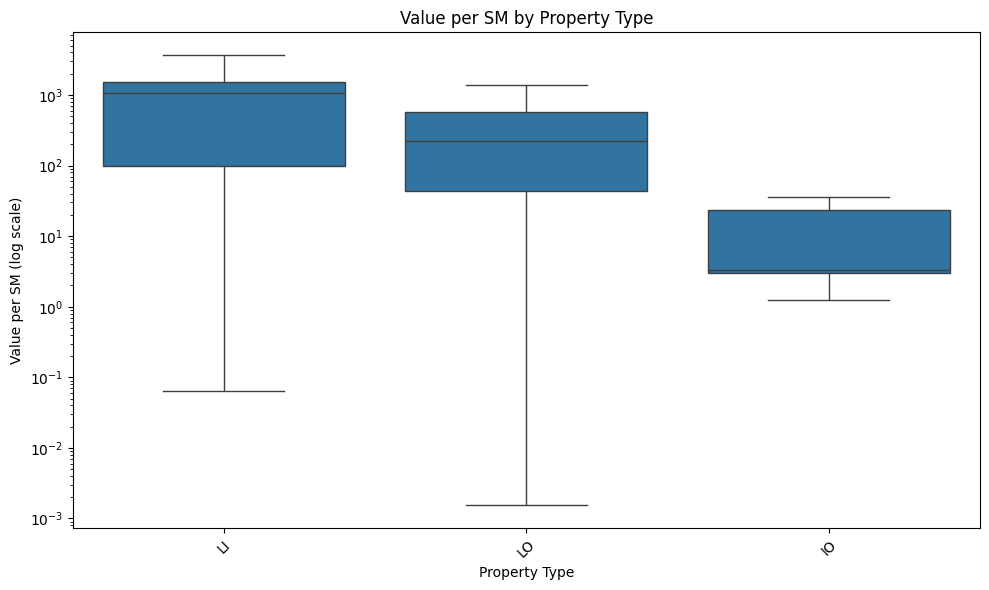

In [64]:
df_plot = df[
    df["PROPERTY_TYPE"].notna() &
    df["VALUE_PER_SM"].notna() &
    (df["VALUE_PER_SM"] > 0)
].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_plot,
    x="PROPERTY_TYPE",
    y="VALUE_PER_SM",
    showfliers=False
)

plt.yscale("log")
plt.xlabel("Property Type")
plt.ylabel("Value per SM (log scale)")
plt.title("Value per SM by Property Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
# Five biggest and smallest assessed values
pd.concat([
    df.nlargest(5, "ASSESSED_VALUE").assign(Group="Top 5"),
    df.nsmallest(5, "ASSESSED_VALUE").assign(Group="Bottom 5")
]).style.format({
    "ASSESSED_VALUE": "{:,.0f}",
    "LAND_SIZE_SM": "{:,.0f}",
    "VALUE_PER_SM": "{:,.2f}"
})

,ROLL_YEAR,ROLL_NUMBER,ADDRESS,ASSESSED_VALUE,ASSESSMENT_CLASS,COMM_CODE,YEAR_OF_CONSTRUCTION,PROPERTY_TYPE,LAND_SIZE_SM,CPID,VALUE_PER_SM,center_longitude,center_latitude,AGE_OF_PROPERTY,DIST_FROM_CENTRE_KM,CITY_AREA,COMM_PROPERTY_COUNT,Group
520624,2023,201443785,4448 FRONT ST SE,"1,589,540,000",NR,SET,2007.000000,LI,"132,600",96146224,"11,987.48",-113.952850,50.882021,16.000000,19.917988,SE,3204,Top 5
520623,2022,201443785,4448 FRONT ST SE,"1,559,870,000",NR,SET,2007.000000,LI,"132,600",96146224,"11,763.73",-113.952850,50.882021,15.000000,19.917988,SE,3204,Top 5
520626,2025,201443785,4448 FRONT ST SE,"1,546,730,000",NR,SET,2007.000000,LI,"132,600",96146224,"11,664.63",-113.952732,50.882073,18.000000,19.916239,SE,3204,Top 5
520625,2024,201443785,4448 FRONT ST SE,"1,533,500,000",NR,SET,2007.000000,LI,"132,600",96146224,"11,564.86",-113.952717,50.882066,17.000000,19.917336,SE,3204,Top 5
687608,2023,202743258,6455 MACLEOD TR SW,"1,101,580,000",NR,MEA,1973.000000,LI,"214,924",960646680,"5,125.45",-114.074457,50.997363,50.000000,5.266722,SW,212,Top 5
765254,2023,646004200,8012 74 AV SE,70,FL,GPI,1999.000000,LO,"45,810",380523450,0.00,-113.923261,50.990453,24.000000,12.020452,SE,106,Bottom 5
765255,2024,646004200,8012 74 AV SE,70,FL,GPI,1999.000000,LO,"45,810",380523450,0.00,-113.923261,50.990453,25.000000,12.020452,SE,106,Bottom 5
765256,2025,646004200,8012 74 AV SE,70,FL,GPI,1999.000000,LO,"45,810",380523450,0.00,-113.923275,50.990459,26.000000,12.019217,SE,106,Bottom 5
379172,2022,200182806,1 TUSCANY GLEN RD NW,120,NR,TUS,2006.500000,LO,24,96082671,4.90,-114.249259,51.118355,15.500000,14.851656,NW,5872,Bottom 5
379173,2023,200182806,1 TUSCANY GLEN RD NW,120,NR,TUS,2006.500000,LO,24,96082671,4.90,-114.249259,51.118355,16.500000,14.851656,NW,5872,Bottom 5


Investigated largest ones and they are legitimate - university, Chinook mall, hospitals, high rise apartment buildings etc. Smallest ones seem a bit suspect - will remove unrealistically low value per sm.

In [66]:
df.nlargest(5, "LAND_SIZE_SM") \
    .style.format({"LAND_SIZE_SM": "{:,.0f}"})

,ROLL_YEAR,ROLL_NUMBER,ADDRESS,ASSESSED_VALUE,ASSESSMENT_CLASS,COMM_CODE,YEAR_OF_CONSTRUCTION,PROPERTY_TYPE,LAND_SIZE_SM,CPID,VALUE_PER_SM,center_longitude,center_latitude,AGE_OF_PROPERTY,DIST_FROM_CENTRE_KM,CITY_AREA,COMM_PROPERTY_COUNT
486252,2022,201162070,9595R 149 ST NW,341070000.000000,NR,HSN,1962.000000,LO,"13,342,400",96136613,25.562867,-114.310008,51.135796,60.000000,19.471812,NW,733
486253,2023,201162070,9595R 149 ST NW,349390000.000000,NR,HSN,1962.000000,LO,"13,342,400",96136613,26.186443,-114.310008,51.135796,61.000000,19.471812,NW,733
486254,2024,201162070,9595R 149 ST NW,374350000.000000,NR,HSN,1962.000000,LO,"13,342,400",96136613,28.057171,-114.310008,51.135796,62.000000,19.471812,NW,733
486255,2025,201162070,9595R 149 ST NW,407620000.000000,NR,HSN,1962.000000,LO,"13,342,400",96136613,30.550726,-114.310022,51.135803,63.000000,19.473054,NW,733
536094,2022,201568060,6465 14 ST NW,209490000.000000,NR,NPK,1979.000000,LO,"10,883,151",96149761,19.249020,-114.106231,51.113424,43.000000,8.009235,NW,8


Again these seem legitimate - parks, waste facilities etc.

In [67]:
df.nlargest(5, "VALUE_PER_SM") \
    .style.format({"VALUE_PER_SM": "{:,.2f}"})

,ROLL_YEAR,ROLL_NUMBER,ADDRESS,ASSESSED_VALUE,ASSESSMENT_CLASS,COMM_CODE,YEAR_OF_CONSTRUCTION,PROPERTY_TYPE,LAND_SIZE_SM,CPID,VALUE_PER_SM,center_longitude,center_latitude,AGE_OF_PROPERTY,DIST_FROM_CENTRE_KM,CITY_AREA,COMM_PROPERTY_COUNT
700705,2022,202893319,1155 CORNERSTONE BV NE,11560000.000000,NR,CNS,2021.000000,LO,5.100000,960644139,"2,266,666.67",-113.940108,51.154967,1.000000,15.330479,NE,3248
71256,2024,39000153,4627R 53 ST NW,380500.000000,NR,VAR,1972.000000,LO,0.200000,930543681,"1,902,500.00",-114.167742,51.094913,52.000000,8.718970,NW,4702
71257,2024,39000153,4627R 53 ST NW,380500.000000,NR,VAR,1972.000000,LO,0.200000,960543684,"1,902,500.00",-114.168552,51.093070,52.000000,8.633468,NW,4702
71258,2025,39000153,4627R 53 ST NW,380500.000000,NR,VAR,1972.000000,LO,0.200000,930543681,"1,902,500.00",-114.167237,51.094985,53.000000,8.696957,NW,4702
71259,2025,39000153,4627R 53 ST NW,380500.000000,NR,VAR,1972.000000,LO,0.200000,960543684,"1,902,500.00",-114.168662,51.093157,53.000000,8.645472,NW,4702


Some are errors some are legitimate e.g high rise apartment buildings. Will remove extremes.

In [68]:
# Remove outliers of values based on assessment class
bounds = (
    df.groupby("ASSESSMENT_CLASS")["VALUE_PER_SM"]
    .agg(
        lower=lambda x: x.quantile(0.01),
        upper=lambda x: x.quantile(0.99)
    )
)

df = df.merge(bounds, on="ASSESSMENT_CLASS", how="left")

keep_mask = (
    (df["VALUE_PER_SM"] >= df["lower"]) &
    (df["VALUE_PER_SM"] <= df["upper"])
)

df_removed_vpsm = df[~keep_mask].copy()
df = df[keep_mask].drop(columns=["lower", "upper"]).copy()

print("Rows kept:", len(df))
print("Rows removed:", len(df_removed_vpsm))

Rows kept: 445875
Rows removed: 9041


# Baseline OLS model

In [69]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1) Drop non-useful columns
# -----------------------------
drop_cols = ["ASSESSED_VALUE", "LAND_SIZE_SM", "ADDRESS", "ROLL_NUMBER", "CPID"]
target_col = "VALUE_PER_SM"

# Keep only useful features (exclude target)
features = [col for col in df_train.columns if col not in drop_cols + [target_col]]

# Force known categorical columns
cat_cols = ["ASSESSMENT_CLASS", "PROPERTY_TYPE", "CITY_AREA", "COMM_CODE"]
num_cols = [col for col in features if col not in cat_cols]

# -----------------------------
# 2) Build train / validation sets
# -----------------------------
train_df = df_train[features + [target_col]].dropna().copy()
val_df = df_val[features + [target_col]].dropna().copy()

# Keep only positive target values
train_df = train_df[train_df[target_col] > 0].copy()
val_df = val_df[val_df[target_col] > 0].copy()

# Log-transform target
train_df["LOG_VALUE_PER_SM"] = np.log(train_df[target_col])
val_df["LOG_VALUE_PER_SM"] = np.log(val_df[target_col])

# -----------------------------
# 3) Preprocessing pipeline
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols)
    ]
)

# -----------------------------
# 4) Ridge regression with CV
# -----------------------------
alphas = np.logspace(-3, 3, 50)

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", RidgeCV(alphas=alphas, store_cv_values=True))
])

X_train = train_df[features]
y_train = train_df["LOG_VALUE_PER_SM"]

X_val = val_df[features]
y_val = val_df["LOG_VALUE_PER_SM"]

ridge_model.fit(X_train, y_train)

# -----------------------------
# 5) Predictions
# -----------------------------
y_train_pred = ridge_model.predict(X_train).ravel()  # ensure 1D
y_val_pred = ridge_model.predict(X_val).ravel()      # ensure 1D

# -----------------------------
# 6) Metrics
# -----------------------------
r2_train_osl = float(r2_score(y_train, y_train_pred))
rmse_train_osl = float(np.sqrt(mean_squared_error(y_train, y_train_pred)))
r2_val_osl = float(r2_score(y_val, y_val_pred))
rmse_val_osl = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Train R-squared:", r2_train_osl)
print("Validation R-squared:", r2_val_osl)
print("Validation RMSE:", rmse_val_osl)


# -----------------------------
# 7) Feature coefficients
# -----------------------------
ohe_features = ridge_model.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(cat_cols)

all_features = num_cols + list(ohe_features)

coef = ridge_model.named_steps['ridge'].coef_
coef_df = pd.DataFrame({"feature": all_features, "coefficient": coef})
coef_df = coef_df.sort_values(by="coefficient", key=abs, ascending=False)
print(coef_df)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Train R-squared: 0.25862042609014724
Validation R-squared: 0.24612954627751238
Validation RMSE: 1.9586415328971263
                 feature  coefficient
8    ASSESSMENT_CLASS_RE            7
39         COMM_CODE_12L           -7
7    ASSESSMENT_CLASS_NR            7
45         COMM_CODE_13K           -6
37         COMM_CODE_12J           -6
..                   ...          ...
274        COMM_CODE_STD           -0
279        COMM_CODE_TEM           -0
127        COMM_CODE_FAL            0
278        COMM_CODE_TAR           -0
192        COMM_CODE_MOR            0

[305 rows x 2 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [70]:
#CHECK VIFs

# Build design matrix from formula (same as OLS)
y, X = patsy.dmatrices(
    """
    LOG_VALUE_PER_SM ~ AGE_OF_PROPERTY
                     + C(ASSESSMENT_CLASS)
                     + C(PROPERTY_TYPE)
                     + C(CITY_AREA)
    """,
    data=train_df,
    return_type="dataframe"
)

# Compute VIF
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df.sort_values("VIF", ascending=False))

                     feature   VIF
0                  Intercept 7,722
3     C(PROPERTY_TYPE)[T.LI]   181
4     C(PROPERTY_TYPE)[T.LO]   180
2  C(ASSESSMENT_CLASS)[T.RE]    60
1  C(ASSESSMENT_CLASS)[T.NR]    59
5         C(CITY_AREA)[T.NW]     2
8         C(CITY_AREA)[T.SE]     2
7         C(CITY_AREA)[T.SW]     2
6         C(CITY_AREA)[T.NE]     2
9            AGE_OF_PROPERTY     1


In [71]:
# RANDOM FOREST EVALUATION

# -----------------------------
# 1) Select features
# -----------------------------
features = [
    "ROLL_YEAR","AGE_OF_PROPERTY",
    "DIST_FROM_CENTRE_KM",
    "center_latitude",
    "center_longitude",
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
    "CITY_AREA"
]

target = "VALUE_PER_SM"

train_df = df_train[features + [target]].copy()
val_df = df_val[features + [target]].copy()

train_df = train_df[train_df[target] > 0].copy()
val_df = val_df[val_df[target] > 0].copy()

train_df["LOG_VALUE_PER_SM"] = np.log(train_df[target])
val_df["LOG_VALUE_PER_SM"] = np.log(val_df[target])

X_train = train_df[features]
y_train = train_df["LOG_VALUE_PER_SM"]

X_val = val_df[features]
y_val = val_df["LOG_VALUE_PER_SM"]

# -----------------------------
# 2) Numeric / categorical columns
# -----------------------------
numeric_features = [
    "ROLL_YEAR","AGE_OF_PROPERTY",
    "DIST_FROM_CENTRE_KM",
    "center_latitude",
    "center_longitude"
]

categorical_features = [
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
    "CITY_AREA"
]
# -----------------------------
# 3) Preprocessing
# -----------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# 4) Random Forest pipeline
# -----------------------------
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=250,
        max_depth=25,
        min_samples_split=10,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
        verbose=1
    ))
])

# -----------------------------
# 5) Fit
# -----------------------------
rf_pipeline.fit(X_train, y_train)

# -----------------------------
# 6) Predict and evaluate
# -----------------------------
y_train_pred = rf_pipeline.predict(X_train)
y_val_pred   = rf_pipeline.predict(X_val)

# -----------------------------
# 7) Metrics (log scale)
# -----------------------------
print("\nTrain R2:", r2_score(y_train, y_train_pred))
print("Train RMSE (log):", np.sqrt(mean_squared_error(y_train, y_train_pred)))

print("\nValidation R2:", r2_score(y_val, y_val_pred))
print("Validation RMSE (log):", np.sqrt(mean_squared_error(y_val, y_val_pred)))

# -----------------------------
# 8) Back to real scale
# -----------------------------
y_val_real = np.exp(y_val)
y_val_pred_real = np.exp(y_val_pred)

# -----------------------------
# 9) Save metrics for comparison
# -----------------------------

r2_train_rf = r2_score(y_train, y_train_pred)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_val_rf = r2_score(y_val, y_val_pred)
rmse_val_rf = np.sqrt(mean_squared_error(y_val, y_val_pred))


rf_model_metrics = pd.DataFrame({
    "model": ["RF_Model"],
    "r2_train": [r2_train_rf],
    "rmse_train": [rmse_train_rf],
    "r2_val": [r2_val_rf],
    "rmse_val": [rmse_val_rf]
})

print("\nValidation RMSE (real):",
      np.sqrt(mean_squared_error(y_val_real, y_val_pred_real)))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   16.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.2s
[Parallel(n_jobs=2)]: Done 250 out of 250 | elapsed:    1.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s



Train R2: 0.8561914046208967
Train RMSE (log): 0.8444924447735899

Validation R2: 0.6941311539442188
Validation RMSE (log): 1.2475967092489395

Validation RMSE (real): 17759.974646334867


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done 250 out of 250 | elapsed:    0.8s finished


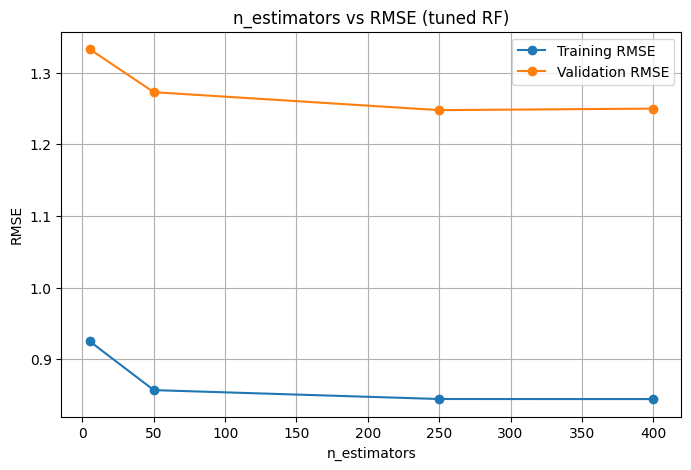

In [72]:
n_estimators_list = [5, 50, 250, 400]

rmse_train_list = []
rmse_val_list = []

for n in n_estimators_list:
    rf_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=n,
            max_depth=25,
            min_samples_split=10,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1,
            verbose=0
        ))
    ])

    rf_pipeline.fit(X_train, y_train)

    # Training RMSE
    y_train_pred = rf_pipeline.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_train_list.append(rmse_train)

    # Validation RMSE
    y_val_pred = rf_pipeline.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    rmse_val_list.append(rmse_val)

# Plot both curves
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, rmse_train_list, marker='o', label="Training RMSE")
plt.plot(n_estimators_list, rmse_val_list, marker='o', label="Validation RMSE")

plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.title("n_estimators vs RMSE (tuned RF)")
plt.legend()
plt.grid()
plt.show()

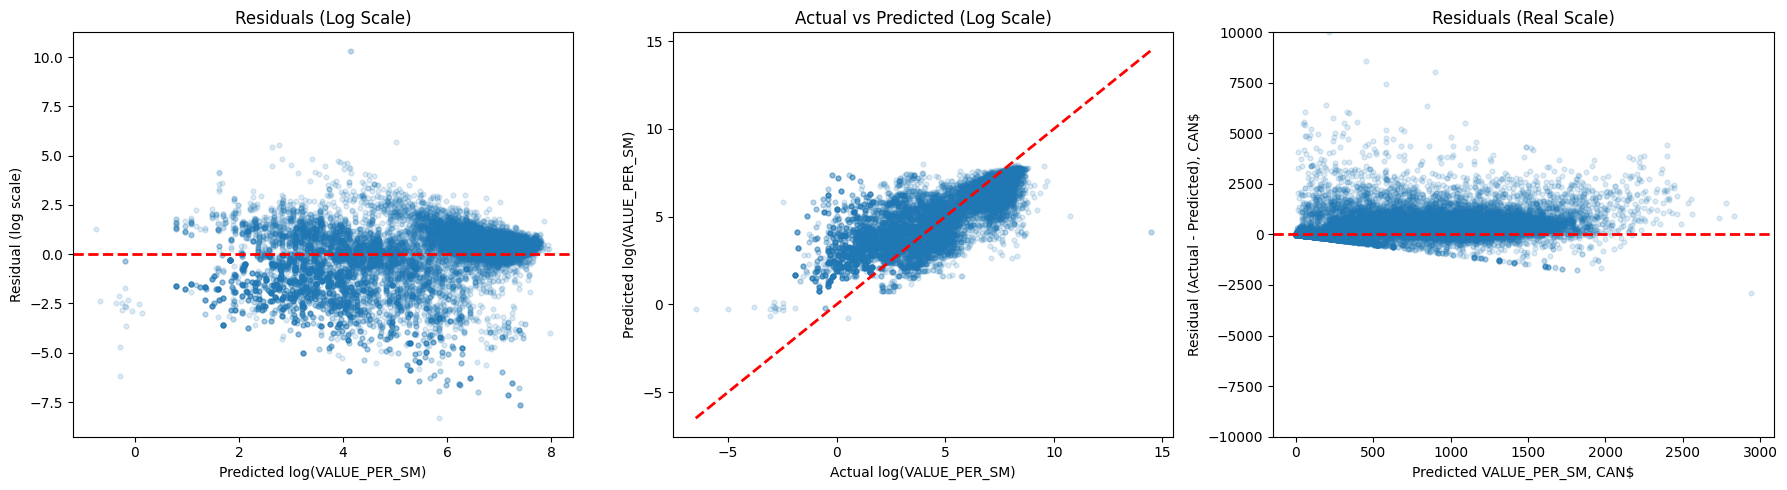

In [73]:
# -----------------------------
# Convert back to real scale
# -----------------------------
y_val_actual = np.exp(y_val)
y_val_pred_real = np.exp(y_val_pred)

# Residuals
residuals_log = y_val - y_val_pred
residuals_real = y_val_actual - y_val_pred_real

# -----------------------------
# Plot side-by-side (3 plots now)
# -----------------------------

plt.figure(figsize=(18, 5))

# --- Plot 1: Log residuals ---
plt.subplot(1, 3, 1)
plt.scatter(y_val_pred, residuals_log, alpha=0.15, s=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted log(VALUE_PER_SM)")
plt.ylabel("Residual (log scale)")
plt.title("Residuals (Log Scale)")

# --- Plot 2: Actual vs Predicted (log scale) ---
plt.subplot(1, 3, 2)
plt.scatter(y_val, y_val_pred, alpha=0.15, s=12)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="red", linestyle="--", linewidth=2)
plt.xlabel("Actual log(VALUE_PER_SM)")
plt.ylabel("Predicted log(VALUE_PER_SM)")
plt.title("Actual vs Predicted (Log Scale)")

# --- Plot 3: Real residuals ---
plt.subplot(1, 3, 3)
plt.scatter(y_val_pred_real, residuals_real, alpha=0.15, s=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted VALUE_PER_SM, CAN$")
plt.ylabel("Residual (Actual - Predicted), CAN$")
plt.title("Residuals (Real Scale)")
plt.ylim(-10000, 10000)


plt.tight_layout()
plt.show()

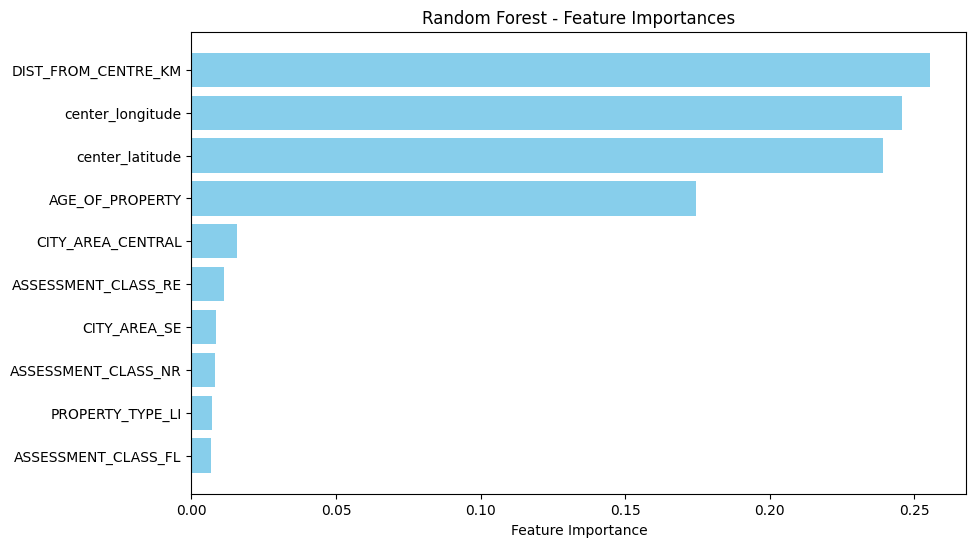

In [74]:
# More important variables to consider for the Random Forest Model


# -----------------------------
# 1) Access the model inside the pipeline
# -----------------------------
rf = rf_pipeline.named_steps["rf"]           # RandomForestRegressor
preproc = rf_pipeline.named_steps["preprocessor"]

# -----------------------------
# 2) Get column names after OneHotEncoder
# -----------------------------
# ColumnTransformer returns transformers by name
cat_encoder = preproc.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Final feature names (numeric + one-hot)
feature_names = numeric_features + list(cat_feature_names)

# -----------------------------
# 3) Get feature importances
# -----------------------------
importances = rf.feature_importances_

# Sort from highest to lowest
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# -----------------------------
# 4) Keep only top 10 features
# -----------------------------
top_n = 10
top_features = sorted_features[:top_n]
top_importances = sorted_importances[:top_n]

# -----------------------------
# 5) Plot
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importances, color="skyblue")
plt.yticks(range(len(top_features)), top_features)
plt.gca().invert_yaxis()  # most important on top
plt.xlabel("Feature Importance")
plt.title("Random Forest - Feature Importances")
plt.show()

In [75]:
# XBOOST

from xgboost import XGBRegressor

# X boost takes into account the direction of optimization

# -----------------------------
# 1) Select features
# -----------------------------
features = [
    "ROLL_YEAR","AGE_OF_PROPERTY",
    "DIST_FROM_CENTRE_KM",
    "center_latitude",
    "center_longitude",
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
    "CITY_AREA"
]

target = "VALUE_PER_SM"

train_df = df_train[features + [target]].copy()
val_df = df_val[features + [target]].copy()

train_df = train_df[train_df[target] > 0].copy()
val_df = val_df[val_df[target] > 0].copy()

train_df["LOG_VALUE_PER_SM"] = np.log(train_df[target])
val_df["LOG_VALUE_PER_SM"] = np.log(val_df[target])

X_train = train_df[features]
y_train = train_df["LOG_VALUE_PER_SM"]

X_val = val_df[features]
y_val = val_df["LOG_VALUE_PER_SM"]

# -----------------------------
# 2) Numeric / categorical columns
# -----------------------------
numeric_features = [
    "ROLL_YEAR","AGE_OF_PROPERTY",
    "DIST_FROM_CENTRE_KM",
    "center_latitude",
    "center_longitude"
]

categorical_features = [
    "ASSESSMENT_CLASS",
    "PROPERTY_TYPE",
    "CITY_AREA"
]
# -----------------------------
# 3) Preprocessing
# -----------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# -----------------------------
# 4) XGBoost dentro de pipeline
# -----------------------------
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.06,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,      # L1 regularization
        reg_lambda=1,     # L2 regularization
        random_state=42,
        n_jobs=-1,
        tree_method="hist"   # Important for large datasets
    ))
])

# -----------------------------
# 5) Fit
# -----------------------------
xgb_pipeline.fit(X_train, y_train)

# -----------------------------
# 6) Predict and evaluate
# -----------------------------
y_train_pred = xgb_pipeline.predict(X_train)
y_val_pred   = xgb_pipeline.predict(X_val)

# -----------------------------
# 7) Save metrics for comparison
# -----------------------------

r2_train_xb = r2_score(y_train, y_train_pred)
rmse_train_xb = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_val_xb = r2_score(y_val, y_val_pred)
rmse_val_xb = np.sqrt(mean_squared_error(y_val, y_val_pred))


xgb_model_metrics = pd.DataFrame({
    "model": ["XGB_Model"],
    "r2_train": [r2_train_xb],
    "rmse_train": [rmse_train_xb],
    "r2_val": [r2_val_xb],
    "rmse_val": [rmse_val_xb]
})


print("Train R-squared:", r2_score(y_train, y_train_pred))
print("Train RMSE (log scale):", np.sqrt(mean_squared_error(y_train, y_train_pred)))

print("Validation R-squared:", r2_score(y_val, y_val_pred))
print("Validation RMSE (log scale):", np.sqrt(mean_squared_error(y_val, y_val_pred)))

Train R-squared: 0.8565393881589904
Train RMSE (log scale): 0.8434700877388863
Validation R-squared: 0.7100272013633043
Validation RMSE (log scale): 1.2147453025232744


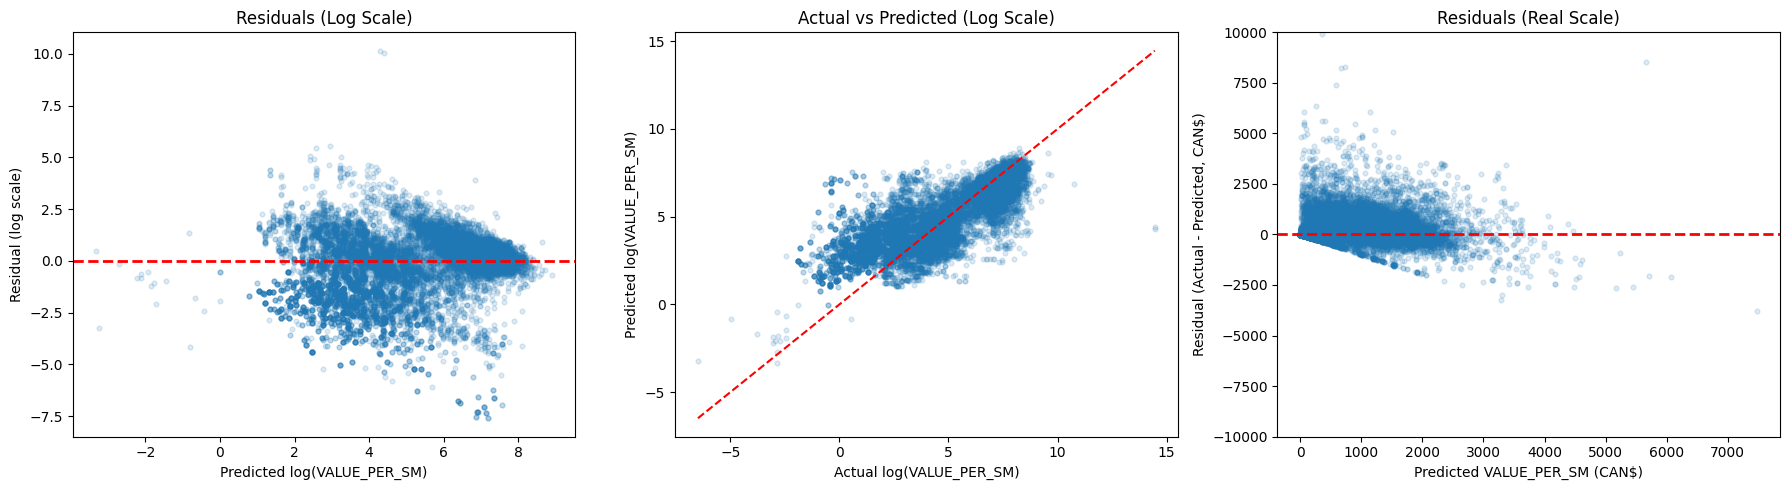

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Convert back to real scale
# -----------------------------
y_val_actual = np.exp(y_val)
y_val_pred_real = np.exp(y_val_pred)

# Residuals
residuals_log = y_val - y_val_pred
residuals_real = y_val_actual - y_val_pred_real

# -----------------------------
# Plot side-by-side (3 plots)
# -----------------------------
plt.figure(figsize=(18, 5))

# --- Plot 1: Log residuals ---
plt.subplot(1, 3, 1)
plt.scatter(y_val_pred, residuals_log, alpha=0.15, s=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Predicted log(VALUE_PER_SM)")
plt.ylabel("Residual (log scale)")
plt.title("Residuals (Log Scale)")

# --- Plot 2: Actual vs Predicted (LOG SCALE) ---
plt.subplot(1, 3, 2)
plt.scatter(y_val, y_val_pred, alpha=0.15, s=12)

# 45-degree line
min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],color="red", linestyle="--")

plt.xlabel("Actual log(VALUE_PER_SM)")
plt.ylabel("Predicted log(VALUE_PER_SM)")
plt.title("Actual vs Predicted (Log Scale)")

# --- Plot 3: Real residuals ---
plt.subplot(1, 3, 3)
plt.scatter(y_val_pred_real, residuals_real, alpha=0.15, s=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.ylim(-10000, 10000)

plt.xlabel("Predicted VALUE_PER_SM (CAN$)")
plt.ylabel("Residual (Actual - Predicted, CAN$)")
plt.title("Residuals (Real Scale)")

plt.tight_layout()
plt.show()

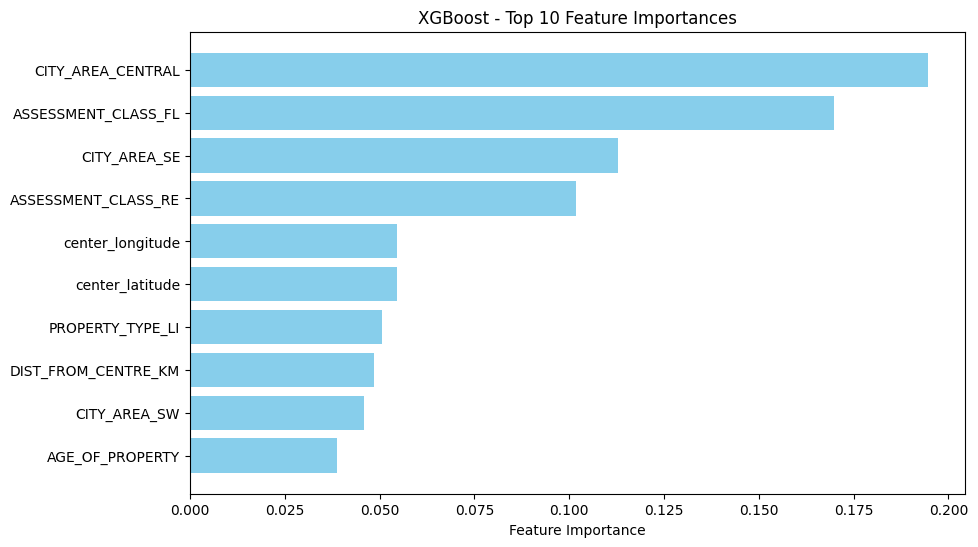

In [77]:

# 1) Access the model inside the pipeline
# -----------------------------
xgb = xgb_pipeline.named_steps["xgb"]       # XGBRegressor
preproc = xgb_pipeline.named_steps["preprocessor"]

# -----------------------------
# 2) Get column names after OneHotEncoder
# -----------------------------
cat_encoder = preproc.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Final feature names (numeric + one-hot)
feature_names = numeric_features + list(cat_feature_names)

# -----------------------------
# 3) Get feature importances
# -----------------------------
importances = xgb.feature_importances_

# Sort from highest to lowest
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# -----------------------------
# 4) Keep only top 10 features
# -----------------------------
top_n = 10
top_features = sorted_features[:top_n]
top_importances = sorted_importances[:top_n]

# -----------------------------
# 5) Plot
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importances, color="skyblue")
plt.yticks(range(len(top_features)), top_features)
plt.gca().invert_yaxis()  # most important on top
plt.xlabel("Feature Importance")
plt.title("XGBoost - Top 10 Feature Importances")
plt.show()

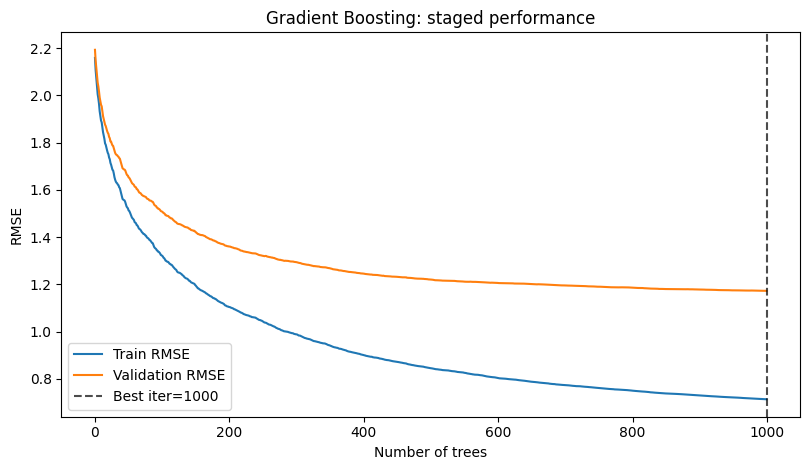

Best validation RMSE=1.172 at n_estimators=1000


In [78]:
# GRADIENT BOOSTING

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1) Apply preprocessing
# -----------------------------
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)

# -----------------------------
# 2) Gradient Boosting configuration
# -----------------------------
staged_cfg = dict(
    learning_rate=0.2,
    n_estimators=1000,
    max_depth=5
)
gb_staged = GradientBoostingRegressor(random_state=607, **staged_cfg)

# -----------------------------
# 3) Fit the model on processed training data
# -----------------------------
gb_staged.fit(X_train_processed, y_train)

# -----------------------------
# 4) Track RMSE for each iteration
# -----------------------------
train_rmse_path = []
val_rmse_path = []

for y_tr_pred, y_val_pred in zip(
    gb_staged.staged_predict(X_train_processed),
    gb_staged.staged_predict(X_val_processed)
):
    train_rmse_path.append(np.sqrt(mean_squared_error(y_train, y_tr_pred)))
    val_rmse_path.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

# -----------------------------
# 5) Identify best iteration
# -----------------------------
best_iter = int(np.argmin(val_rmse_path)) + 1
best_rmse = float(np.min(val_rmse_path))

# -----------------------------
# 6) Plot RMSE evolution
# -----------------------------
plt.figure(figsize=(8.2, 4.8))
plt.plot(train_rmse_path, label='Train RMSE')
plt.plot(val_rmse_path, label='Validation RMSE')
plt.axvline(best_iter, color='k', linestyle='--', alpha=0.7,
            label=f'Best iter={best_iter}')
plt.title('Gradient Boosting: staged performance')
plt.xlabel('Number of trees')
plt.ylabel('RMSE')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Save metrics for comparison
# -----------------------------

r2_train_gb = r2_score(y_train, y_tr_pred)
rmse_train_gb = np.sqrt(mean_squared_error(y_train, y_tr_pred))

r2_val_gb = r2_score(y_val, y_val_pred)
rmse_val_gb = np.sqrt(mean_squared_error(y_val, y_val_pred))



print(f'Best validation RMSE={best_rmse:.3f} at n_estimators={best_iter}')

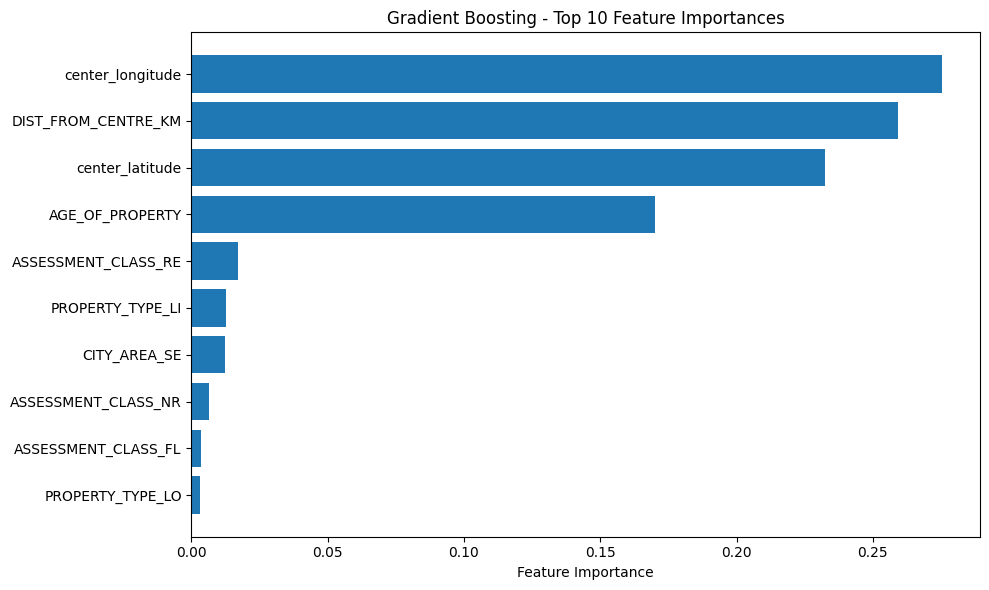

In [79]:
# Gradient Boost Model

# -----------------------------
# 1) Use your trained model and preprocessor
# -----------------------------
gb = gb_staged              # your trained GradientBoostingRegressor
preproc = preprocessor      # your preprocessor

# -----------------------------
# 2) Get column names after OneHotEncoder
# -----------------------------
cat_encoder = preproc.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)

# Final feature names (numeric + one-hot)
feature_names = numeric_features + list(cat_feature_names)

# -----------------------------
# 3) Get feature importances
# -----------------------------
importances = gb.feature_importances_

# Sort from highest to lowest
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# -----------------------------
# 4) Keep only top 10 features
# -----------------------------
top_n = 10
top_features = sorted_features[:top_n]
top_importances = sorted_importances[:top_n]

# -----------------------------
# 5) Plot
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importances)
plt.yticks(range(len(top_features)), top_features)
plt.gca().invert_yaxis()  # most important on top
plt.xlabel("Feature Importance")
plt.title("Gradient Boosting - Top 10 Feature Importances")
plt.tight_layout()
plt.show()

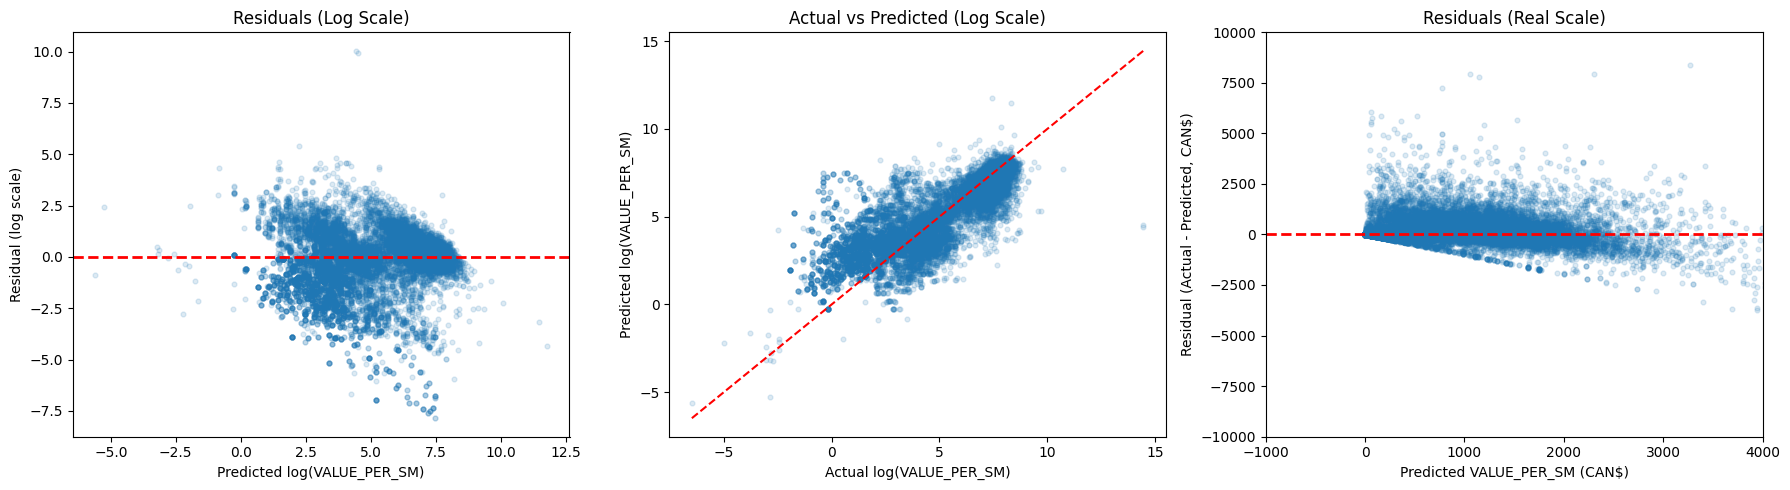

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Convert back to real scale
# -----------------------------
y_val_actual = np.exp(y_val)
y_val_pred_real = np.exp(y_val_pred)

# Residuals
residuals_log = y_val - y_val_pred
residuals_real = y_val_actual - y_val_pred_real

# -----------------------------
# Plot side-by-side (3 plots)
# -----------------------------
plt.figure(figsize=(18, 5))

# --- Plot 1: Log residuals ---
plt.subplot(1, 3, 1)
plt.scatter(y_val_pred, residuals_log, alpha=0.15, s=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Predicted log(VALUE_PER_SM)")
plt.ylabel("Residual (log scale)")
plt.title("Residuals (Log Scale)")

# --- Plot 2: Actual vs Predicted (LOG SCALE) ---
plt.subplot(1, 3, 2)
plt.scatter(y_val, y_val_pred, alpha=0.15, s=12)

# 45-degree line
min_val = min(y_val.min(), y_val_pred.min())
max_val = max(y_val.max(), y_val_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],color="red", linestyle="--")

plt.xlabel("Actual log(VALUE_PER_SM)")
plt.ylabel("Predicted log(VALUE_PER_SM)")
plt.title("Actual vs Predicted (Log Scale)")

# --- Plot 3: Real residuals ---
plt.subplot(1, 3, 3)
plt.scatter(y_val_pred_real, residuals_real, alpha=0.15, s=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.ylim(-10000, 10000)
plt.xlim(-1000, 4000)
plt.xlabel("Predicted VALUE_PER_SM (CAN$)")
plt.ylabel("Residual (Actual - Predicted, CAN$)")
plt.title("Residuals (Real Scale)")

plt.tight_layout()
plt.show()

In [81]:
print(f"""
Model           | Train R² | Train RMSE | Validation R² | Validation RMSE
------------------------------------------------------------------------
OLS_RidgeCV     | {r2_train_osl:.4f}     | {rmse_train_osl:.4f}   | {r2_val_osl:.4f}       | {rmse_val_osl:.4f}
Random Forest   | {r2_train_rf:.4f}     | {rmse_train_rf:.4f}   | {r2_val_rf:.4f}       | {rmse_val_rf:.4f}
XGBoost         | {r2_train_xb:.4f}     | {rmse_train_xb:.4f}   | {r2_val_xb:.4f}       | {rmse_val_xb:.4f}
Gradient Boost  | {r2_train_gb:.4f}     | {rmse_train_gb:.4f}   | {r2_val_gb:.4f}       | {rmse_val_gb:.4f}
""")


Model           | Train R² | Train RMSE | Validation R² | Validation RMSE
------------------------------------------------------------------------
OLS_RidgeCV     | 0.2586     | 1.9174   | 0.2461       | 1.9586
Random Forest   | 0.8562     | 0.8445   | 0.6941       | 1.2476
XGBoost         | 0.8565     | 0.8435   | 0.7100       | 1.2147
Gradient Boost  | 0.8974     | 0.7131   | 0.7299       | 1.1723



In [82]:
print(f"""
Model           | Train R² | Train RMSE | Validation R² | Validation RMSE
------------------------------------------------------------------------
OLS_RidgeCV     | {r2_train_osl:.4f}     | {rmse_train_osl:.4f}   | {r2_val_osl:.4f}       | {rmse_val_osl:.4f}
Random Forest   | {r2_train_rf:.4f}     | {rmse_train_rf:.4f}   | {r2_val_rf:.4f}       | {rmse_val_rf:.4f}
Gradient Boost  | {r2_train_gb:.4f}     | {rmse_train_gb:.4f}   | {r2_val_gb:.4f}       | {rmse_val_gb:.4f}
""")


Model           | Train R² | Train RMSE | Validation R² | Validation RMSE
------------------------------------------------------------------------
OLS_RidgeCV     | 0.2586     | 1.9174   | 0.2461       | 1.9586
Random Forest   | 0.8562     | 0.8445   | 0.6941       | 1.2476
Gradient Boost  | 0.8974     | 0.7131   | 0.7299       | 1.1723

